In [2]:
#preapring datasets

import pandas as pd

df=pd.read_csv("train.tsv",sep='\t',header=None)
print(f'the shape of train dataset is::{df.shape}')
df_test=pd.read_csv("test.tsv",sep='\t',header=None)
print(f'the shape of test dataset is::{df_test.shape}')
# print(df.head())

columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state",
    "party",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]
df.columns=columns
df_test.columns=columns

df=df[['statement','label']]
df_test=df_test[['statement','label']]

df.dropna(inplace=True)
df_test.dropna(inplace=True)

def convert_label(x):
    if x in ["true", "mostly-true",'half-true']:
        return 1
    else:
        return 0

df["label"] = df["label"].apply(convert_label)
df_test['label']=df_test["label"].apply(convert_label)
# print(df_test)
# print(df.shape)
print(df['label'].value_counts())
df['statement'].head(6)
df_test['statement'].head(6)
print(df_test['label'].value_counts())
print(df.head())

the shape of train dataset is::(10240, 14)
the shape of test dataset is::(1267, 14)
label
1    5752
0    4488
Name: count, dtype: int64
label
1    714
0    553
Name: count, dtype: int64
                                           statement  label
0  Says the Annies List political group supports ...      0
1  When did the decline of coal start? It started...      1
2  Hillary Clinton agrees with John McCain "by vo...      1
3  Health care reform legislation is likely to ma...      0
4  The economic turnaround started at the end of ...      1


In [3]:
#NLP preprocessing

import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text) #removing number with ''
    text = re.sub(r"[^\w\s]", "", text) #remove puncatations
    text = re.sub(r"\s+", " ", text).strip() #remove the extra spaces
    return text

df["statement"] = df["statement"].apply(clean_text)
df_test['statement']=df_test['statement'].apply(clean_text)


##splilting the dataset inorder to tokenized 
from sklearn.model_selection import train_test_split

X_train,y_train=df['statement'],df['label']
X_test,y_test=df_test['statement'],df_test['label']


#tokenIZXATIONS

from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 11173

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)
print(len(tokenizer.word_index))#this say my dataset has only 11174 unique words

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(len(X_train_seq))
print(X_train.size)
#NLP preprocessing


print('Tokenize exmaple::')
print(X_train_seq[5502])
print(X_train.iloc[5502])



12423
10240
10240
Tokenize exmaple::
[1, 2708, 168, 156, 2070, 52, 41, 3789, 20, 3871, 11, 295, 1904]
the fulton county vote count will be finished by pm on election night


In [4]:
import numpy as np

length=[len(seq) for seq in X_train_seq]
print(len(X_train))
print (max(length))
print(min(length))

padd_len=int(np.percentile(length,95))
print(padd_len)

# indices = [i for i, seq in enumerate(X_train_seq) if len(seq) ==8]
# print(indices[:10])  # show first 10
##paddding all the token to make 95 percent of the data atleaset the size of 32

from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad=pad_sequences(X_train_seq,maxlen=padd_len,padding='pre')
X_test_pad=pad_sequences(X_test_seq,maxlen=padd_len,padding='pre')

print(f"The x_train_padded example ::{X_train_pad[5502]}")
print(X_train_pad.shape)
print(X_test_pad.shape)


10240
396
2
31
The x_train_padded example ::[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    1 2708  168  156 2070   52   41 3789   20 3871
   11  295 1904]
(10240, 31)
(1267, 31)


Text
 ↓
Tokenization → [2, 1, 3]
 ↓
Embedding → [[vector], [vector], [vector]]
 ↓
LSTM → learns patterns

In [5]:
embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = list(map(float, values[1:]))
        embedding_index[word] = vector

import numpy as np

embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector
print(embedding_matrix[1])

[-0.038194 -0.24487   0.72812  -0.39961   0.083172  0.043953 -0.39141
  0.3344   -0.57545   0.087459  0.28787  -0.06731   0.30906  -0.26384
 -0.13231  -0.20757   0.33395  -0.33848  -0.31743  -0.48336   0.1464
 -0.37304   0.34577   0.052041  0.44946  -0.46971   0.02628  -0.54155
 -0.15518  -0.14107  -0.039722  0.28277   0.14393   0.23464  -0.31021
  0.086173  0.20397   0.52624   0.17164  -0.082378 -0.71787  -0.41531
  0.20335  -0.12763   0.41367   0.55187   0.57908  -0.33477  -0.36559
 -0.54857  -0.062892  0.26584   0.30205   0.99775  -0.80481  -3.0243
  0.01254  -0.36942   2.2167    0.72201  -0.24978   0.92136   0.034514
  0.46745   1.1079   -0.19358  -0.074575  0.23353  -0.052062 -0.22044
  0.057162 -0.15806  -0.30798  -0.41625   0.37972   0.15006  -0.53212
 -0.2055   -1.2526    0.071624  0.70565   0.49744  -0.42063   0.26148
 -1.538    -0.30223  -0.073438 -0.28312   0.37104  -0.25217   0.016215
 -0.017099 -0.38984   0.87424  -0.72569  -0.51058  -0.52028  -0.1459
  0.8278    0.27062 ]

In [6]:
#Implementing it on simple lstm models

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,Embedding,GRU,SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
model=Sequential()
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=100,
    weights=[embedding_matrix],
    input_length=padd_len,
    trainable=True,
    mask_zero=True
))

model.add(LSTM(16))
model.add(Dropout(0.7))
model.add(Dense(8,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
history=model.fit(
    X_train_pad,y_train,
    epochs=10,batch_size=32,
    callbacks=[early_stop],
    validation_split=0.2
)
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)
y_pred_prob=model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")





C:\Users\AWANTIKA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5099 - loss: 0.7075 - val_accuracy: 0.5464 - val_loss: 0.6878
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5549 - loss: 0.6884 - val_accuracy: 0.5469 - val_loss: 0.6870
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5610 - loss: 0.6846 - val_accuracy: 0.5474 - val_loss: 0.6862
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5687 - loss: 0.6819 - val_accuracy: 0.5483 - val_loss: 0.6852
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5753 - loss: 0.6791 - val_accuracy: 0.5474 - val_loss: 0.6824
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5875 - loss: 0.6710 - val_accuracy: 0.5635 - val_loss: 0.6753
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6066 - loss: 0.6620 - val_accuracy: 0.5747 - val_loss: 0.6708
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6349 - loss: 0.6442 - val_acc

              precision    recall  f1-score   support

           0       0.54      0.36      0.43       553
           1       0.60      0.76      0.67       714

    accuracy                           0.58      1267
   macro avg       0.57      0.56      0.55      1267
weighted avg       0.57      0.58      0.57      1267

Accuracy : 0.5840568271507498
Precision: 0.6042363433667781
Recall   : 0.7591036414565826
F1 Score : 0.6728739913097455


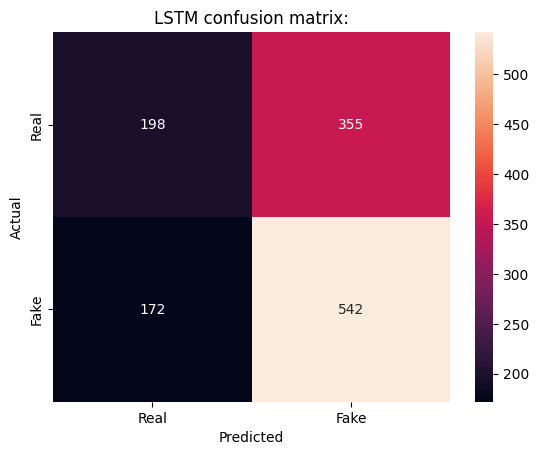

In [ ]:
import seaborn as sns
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cn_m = confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))


print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1 Score : {f1}")

plt.figure()
sns.heatmap(cn_m, annot=True, fmt="d",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.title("LSTM confusion matrix:")
plt.show()

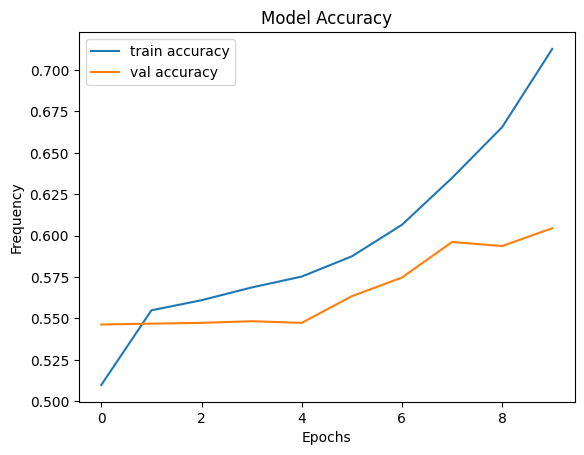

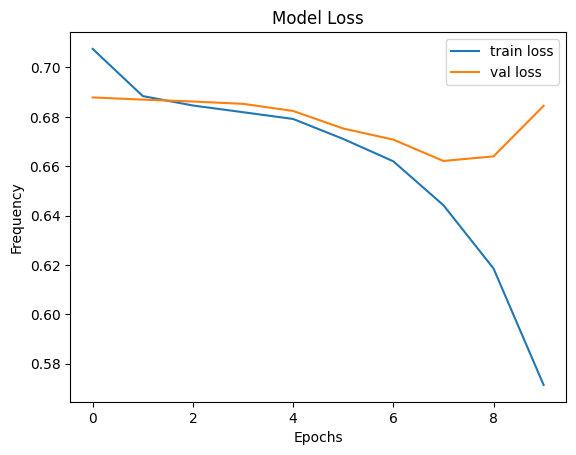

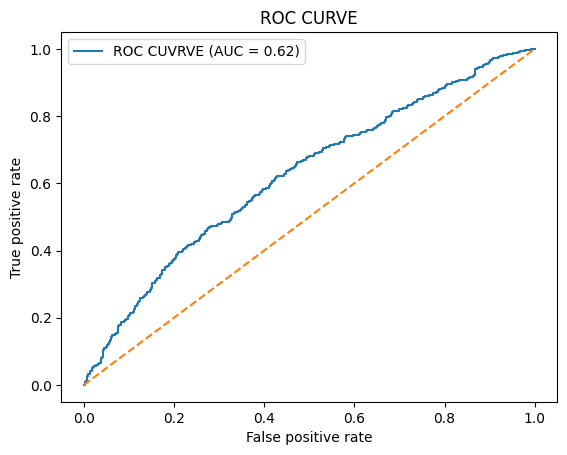

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc

plt.figure()
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='val accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Frequency")
plt.legend()
plt.show()

fpr,tpr,threshold = roc_curve(y_test,y_pred_prob)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label = f'ROC CUVRVE (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()

In [9]:
#implementing using bilstm

from tensorflow.keras.layers import Bidirectional

bidirection=Sequential()
bidirection.add(Embedding(
    input_dim=vocab_size,
    trainable=True,
    mask_zero=True,
    weights=[embedding_matrix],
    input_length=padd_len,
    output_dim=100
))

bidirection.add(
    SpatialDropout1D(0.3)
)
bidirection.add(Bidirectional(LSTM(16)))
bidirection.add(Dropout(0.5))
bidirection.add(Dense(8,activation='relu'))
bidirection.add(Dropout(0.4))
bidirection.add(Dense(1,activation='sigmoid'))

bidirection.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
    )
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)
history=bidirection.fit(
    X_train_pad,y_train,
    epochs=10,batch_size=32,
    callbacks=[early_stop],
    validation_split=0.2
)
loss, acc = bidirection.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)
y_pred_prob=bidirection.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")


Epoch 1/10


C:\Users\AWANTIKA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


256/256 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.5385 - loss: 0.6957 - val_accuracy: 0.5464 - val_loss: 0.6847
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5579 - loss: 0.6846 - val_accuracy: 0.5488 - val_loss: 0.6829
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5592 - loss: 0.6823 - val_accuracy: 0.5479 - val_loss: 0.6826
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5642 - loss: 0.6789 - val_accuracy: 0.5479 - val_loss: 0.6726
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5657 - loss: 0.6772 - val_accuracy: 0.5483 - val_loss: 0.6723
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5723 - loss: 0.6716 - val_accuracy: 0.5586 - val_loss: 0.6675
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5785 - loss: 0.6686 - val_accuracy: 0.5601 - val_loss: 0.6668
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5892 - loss: 0.6607 - val_accuracy: 0.57

              precision    recall  f1-score   support

           0       0.56      0.38      0.45       553
           1       0.61      0.77      0.68       714

    accuracy                           0.60      1267
   macro avg       0.58      0.57      0.57      1267
weighted avg       0.59      0.60      0.58      1267

Accuracy : 0.5966850828729282
Precision: 0.6136618141097424
Recall   : 0.7675070028011205
F1 Score : 0.6820161792159303


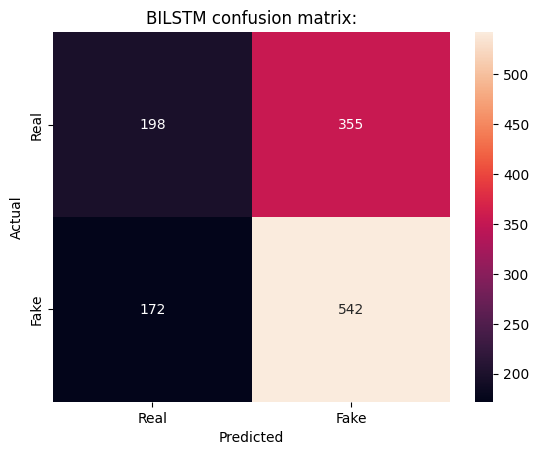

In [10]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(classification_report(y_test,y_pred))

print(f"Accuracy : {accuracy}")
print(f"Precision: {precision}")
print(f"Recall   : {recall}")
print(f"F1 Score : {f1}")

plt.figure()
sns.heatmap(cn_m, annot=True, fmt="d",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BILSTM confusion matrix:")
plt.show()


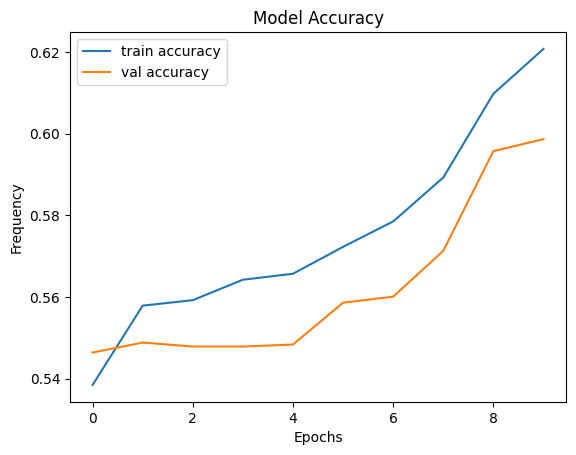

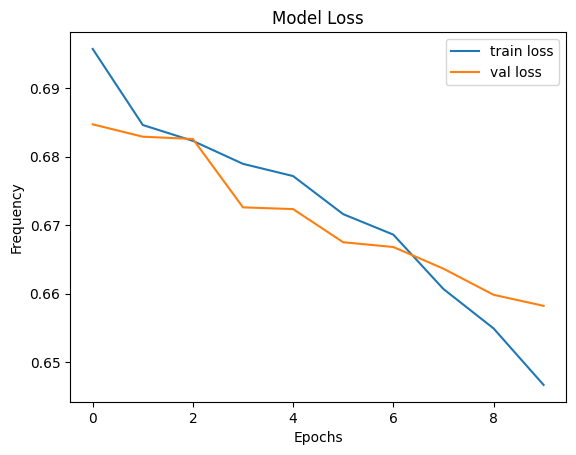

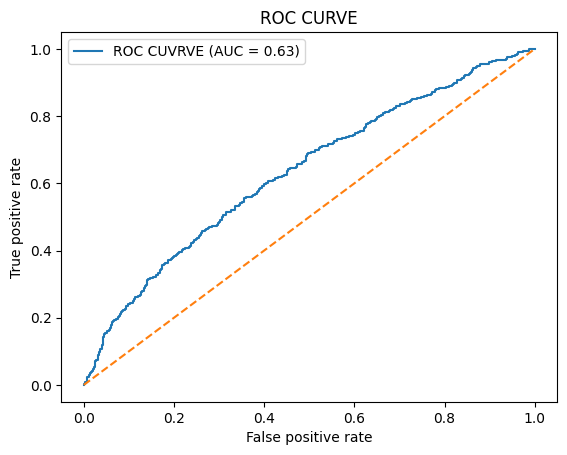

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc

plt.figure()
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='val accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Frequency")
plt.legend()
plt.show()

fpr,tpr,threshold = roc_curve(y_test,y_pred_prob)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label = f'ROC CUVRVE (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()
